In [1]:
# %matplotlib inline
from matplotlib import pyplot as plt
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [18]:
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [16]:
alexnet = models.AlexNet()
print(alexnet)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

(np.float64(-0.5), np.float64(1279.5), np.float64(935.5), np.float64(-0.5))

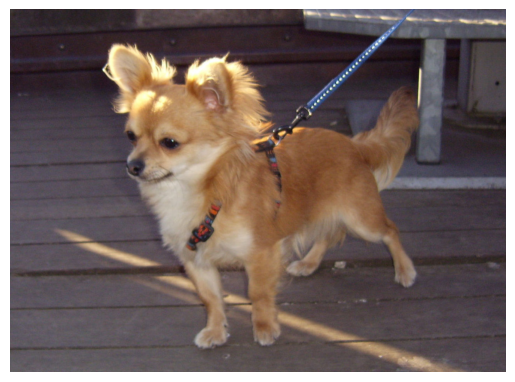

In [4]:
from PIL import Image
img = Image.open('bobby.jpg')
# img.show()
plt.imshow(img)
plt.axis('off')

In [11]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize((316,256)),
    # transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])
img_t = preprocess(img)

In [12]:

batch_t = torch.unsqueeze(img_t, 0)
print(batch_t.shape)
print(batch_t)

torch.Size([1, 3, 316, 256])
tensor([[[[0.2549, 0.2353,  ..., 0.2980, 0.3059],
          [0.2431, 0.2235,  ..., 0.3137, 0.3059],
          ...,
          [0.3804, 0.3765,  ..., 0.2980, 0.2980],
          [0.3882, 0.3882,  ..., 0.3216, 0.3216]],

         [[0.2275, 0.2157,  ..., 0.2902, 0.2824],
          [0.2157, 0.2118,  ..., 0.3020, 0.2902],
          ...,
          [0.3608, 0.3765,  ..., 0.2745, 0.2784],
          [0.3765, 0.3804,  ..., 0.2784, 0.2824]],

         [[0.2275, 0.2196,  ..., 0.3098, 0.3373],
          [0.2118, 0.2000,  ..., 0.3569, 0.3686],
          ...,
          [0.3647, 0.3765,  ..., 0.2941, 0.2941],
          [0.3922, 0.3843,  ..., 0.3020, 0.2980]]]])


In [13]:
alexnet.eval()
out = alexnet(batch_t)
print(out)

tensor([[-4.4552e-03,  6.1782e-03,  7.0592e-03,  7.6904e-03,  1.8723e-03,
          6.5874e-03,  1.2849e-02,  4.2426e-03,  9.7318e-03, -3.4188e-03,
          3.6626e-03, -3.3115e-03, -6.6293e-03,  1.0826e-02,  7.8958e-03,
          1.2027e-02,  8.8372e-03,  5.9943e-03,  8.7136e-03,  5.1478e-03,
         -3.2828e-03,  8.6920e-03, -4.7131e-03,  7.5416e-03, -3.0649e-03,
          1.7204e-02,  1.1043e-02,  1.0289e-02, -7.2233e-03, -1.7123e-02,
         -1.2054e-02,  9.1925e-03, -1.7168e-02,  9.9094e-03, -2.7539e-03,
         -5.5902e-03,  1.1835e-02, -2.7233e-03,  1.1848e-02,  1.6638e-03,
          9.0618e-03,  3.0743e-03,  3.0762e-03,  1.4427e-02, -3.7572e-03,
         -1.3635e-02,  9.8285e-03,  5.3963e-03, -1.1407e-02, -1.4839e-02,
         -1.2037e-02, -3.2104e-03,  1.4040e-02,  1.0171e-02, -2.3208e-03,
         -1.2408e-03, -1.5295e-03,  4.1118e-03, -1.0417e-02,  4.3051e-03,
          6.2481e-03,  8.4596e-03, -3.2088e-03, -1.4642e-02, -1.3866e-02,
          1.1887e-02,  1.1058e-02, -1.

In [27]:
from torchvision.transforms import ToPILImage
out_t = (out.data.squeeze() + 1.0) / 2.0
out_img = ToPILImage()(out_t)
out_img

ValueError: pic should be 2/3 dimensional. Got 1 dimensions.